## Simplified self-attention

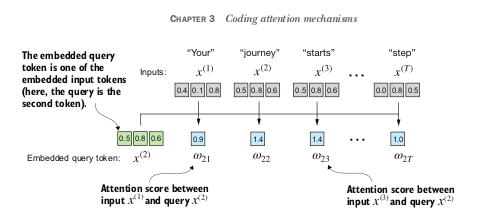   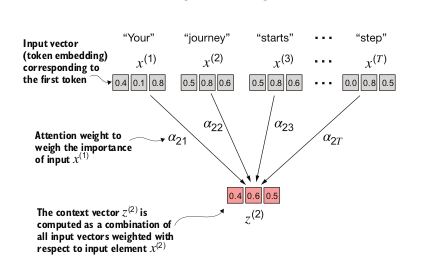   

Idea is to generate context vector (so new embedding for certain token) based on value of other tokens in the input - to give "context" to each token, based on whole input.  
Steps for each input embedding (called query):
- calculate **attention score** between query and rest of tokens (token embeddings), output would be an array of w21, w22, w23, w2x attention scores for each query
- normalize scores with softmax to **attention weights**; it says how important is some token to the query
- multiply each token (embedding) with it's attention weight - it will result in **context vector**; it has information from all input tokens within

Code example for one of the tokens (x2):

In [4]:
import torch

inputs = torch.tensor(
[[0.43, 0.15, 0.89], # x1 # Your
[0.55, 0.87, 0.66],  # x2 # journey
[0.57, 0.85, 0.64],  # x3 # starts
[0.22, 0.58, 0.33],  # x4 # with
[0.77, 0.25, 0.10],  # x5 # one
[0.05, 0.80, 0.55]]  # x6 # step
)

x2 = inputs[1]
x2_att_scores = torch.empty(inputs.shape[0]) # how closely related is each of the embeddings (x1,x2,x3,x4,x5,x6) with x2

for idx, _ in enumerate(inputs):
    x2_att_scores[idx] = torch.dot(x2, inputs[idx])

x2_att_weights = torch.softmax(x2_att_scores, 0) # normalized scores
z2 = torch.zeros(x2.shape)

for idx, _ in enumerate(inputs):
    z2 += x2_att_weights[idx] * inputs[idx]
    
print(inputs)
print(x2_att_scores)
print(x2_att_weights)
print(z2)


tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])
tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor([0.4419, 0.6515, 0.5683])


## Self-attention with trainable weights

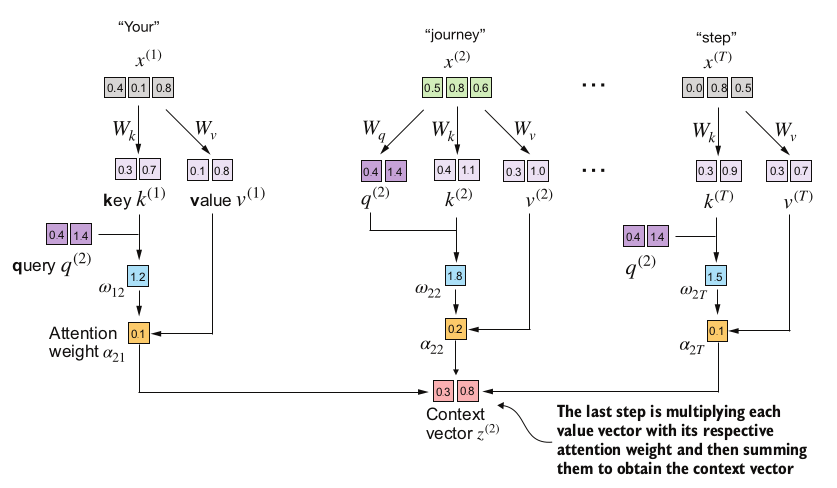

Idea is to generate 3 embeddings out of each token -> query (q), key (k) and value (v) size (arbitriary selected) of 2 using trainable weight matrices W<sub>q</sub>, W<sub>k</sub>, W<sub>v</sub>.  
Those matrices have size of 3x2 to  fit into matrix multiplication requirements.
After that we do similar steps as before - so we calculate attention weights, **BUT** using query _q<sub>2</sub>_ instead of x<sub>2</sub> and multiply it with key _k<sub>2</sub>_  (and normalize afterwards)
After weights are calculated, context vector is obtained by multiplying weight with each value vector _v<sub>x</sub>_

In [5]:
inputs = torch.tensor(
[[0.43, 0.15, 0.89], # x1 # Your
[0.55, 0.87, 0.66],  # x2 # journey
[0.57, 0.85, 0.64],  # x3 # starts
[0.22, 0.58, 0.33],  # x4 # with
[0.77, 0.25, 0.10],  # x5 # one
[0.05, 0.80, 0.55]]  # x6 # step
)
d_in = inputs.shape[1] # shape = 6x3, shape[1] = 3
x_2 = inputs[1]
d_out = 2

torch.manual_seed(123)
W_q = torch.nn.Parameter(torch.rand((d_in, d_out))) 
W_k = torch.nn.Parameter(torch.rand((d_in, d_out)))
W_v = torch.nn.Parameter(torch.rand((d_in, d_out))) 

query_2 = x_2 @ W_q # single transformation from x_2 to query using W_q

queries = inputs @ W_q
keys = inputs @ W_k
values = inputs @ W_v

keys_2 = keys[1]
d_k = keys.shape[1] #2
attn_score_22 = torch.dot(query_2, keys_2)
attn_scores_2 = query_2 @ keys.T
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
context_vec_2 = attn_weights_2 @ values

# print(x_2)
# print(W_q)
# print(query_2)
# print(queries)
# print(keys)
# print(values)
print(context_vec_2)

tensor([0.3061, 0.8210], grad_fn=<SqueezeBackward4>)


## Self-attention class

Just to wrap everything into nice class. Note: it's called via `sa_v2(inputs)` because `nn.Module` implementation overwrites `__call()__` with overwritten `forward()` method.

In [6]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, inputs):
        queries = self.W_query(inputs)
        keys = self.W_key(inputs)
        values = self.W_value(inputs)
        
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        context_vec = attn_weights @ values
        return context_vec

torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))


tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


### Casual and dropout masks

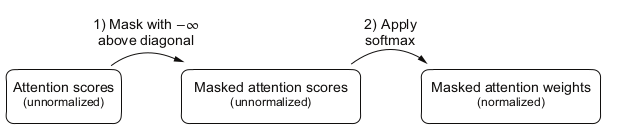
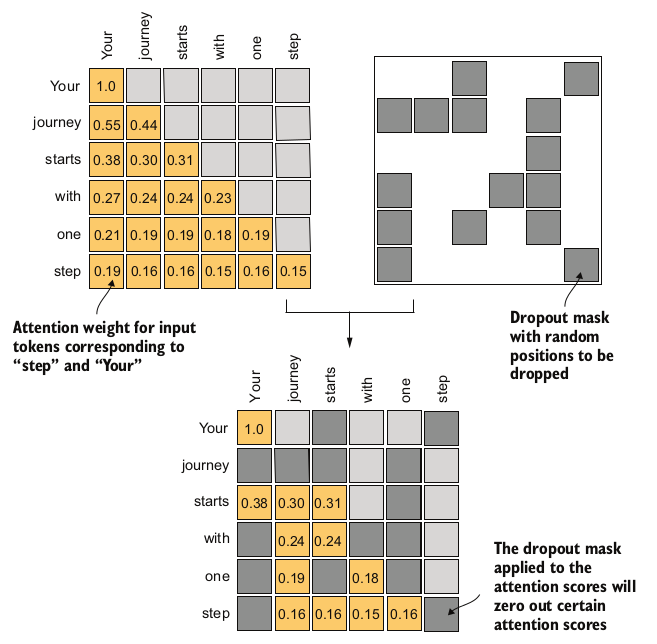

Idea is to add masking of not-yet-known tokens in the sequence. Algorithm shouldn't have knowledge about future tokens. Dropout is deleting some of the weights randomly to prevent overfitting.   
Apparently it's not used anymore, but implemented for completeness.

In [7]:
class CausalAttention(nn.Module):
    def __init__(self, d_in: int, d_out: int, context_length: int, dropout: float, qkv_bias=False):
        super().__init__()
        self.W_query= torch.nn.Linear(d_in, d_out, bias = qkv_bias) 
        self.W_key = torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.W_value = torch.nn.Linear(d_in, d_out, bias = qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.casual_mask : torch.Tensor
        self.register_buffer(
            name="casual_mask",
            tensor=torch.triu(torch.ones(context_length, context_length, dtype=torch.bool), diagonal=1)
        )

    def forward(self, inputs):
        b, num_tokens, d_in = inputs.shape
        queries = self.W_query(inputs)
        keys = self.W_key(inputs)
        values = self.W_value(inputs)

        # print(f'inputs.shape = ${inputs.shape}')
        # print(f'W_query shape -> d_in = {d_in}, d_out = {d_out}')
        # print(f'queries.shape = ${queries.shape}')

        attn_scores: torch.Tensor = queries @ keys.transpose(1,2)

        attn_scores.masked_fill_(self.casual_mask[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values
        return context_vec


In [8]:
torch.manual_seed(789)
d_out = 2 #arbirtiarly selected
batch_inputs = torch.stack((inputs, inputs))
d_in = batch_inputs.shape[-1] #embedding size - 3 values per token
context_length = batch_inputs.shape[1]
ca = CausalAttention(d_in, d_out, inputs.shape[0], 0.)
ca(batch_inputs)

tensor([[[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]],

        [[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]]], grad_fn=<UnsafeViewBackward0>)

## Multi-head attention

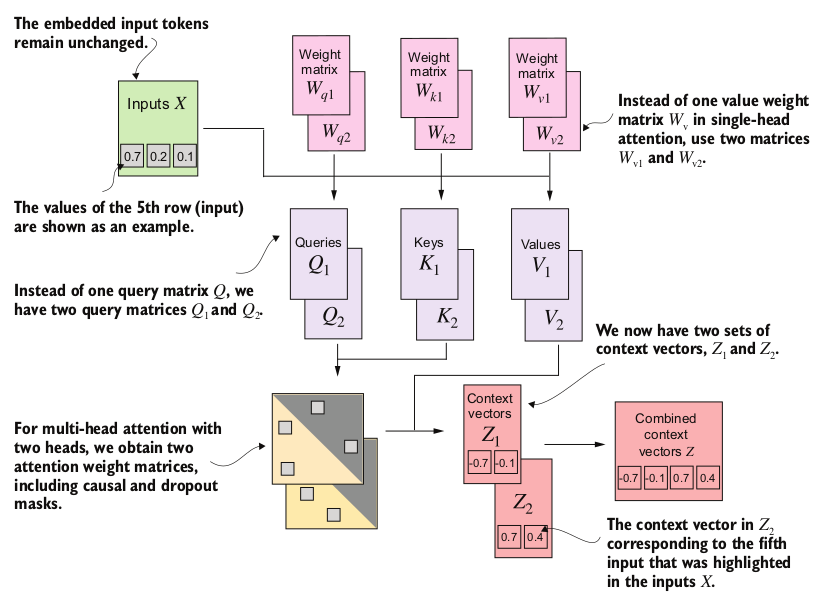

Idea is to add another set of weight matrices and calculate another set of context vectors out of it and merging it at the end. Simliest way is to wrap it over out single-head attention class.

In [9]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads=2, qkv_bias=False):
        super().__init__()
        print(dropout)
        self.heads = nn.ModuleList([
            CausalAttention(d_in, d_out, context_length, dropout, qkv_bias) for _ in range(num_heads)
        ])

    def forward(self, inputs):
        context_vectors = torch.cat([head(inputs) for head in self.heads], dim=-1)
        return context_vectors

torch.manual_seed(123)
context_length = batch_inputs.shape[1]
d_in, d_out = batch_inputs.shape[-1], 2
dropout = 0.

mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, dropout)
mha(batch_inputs)

0.0


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

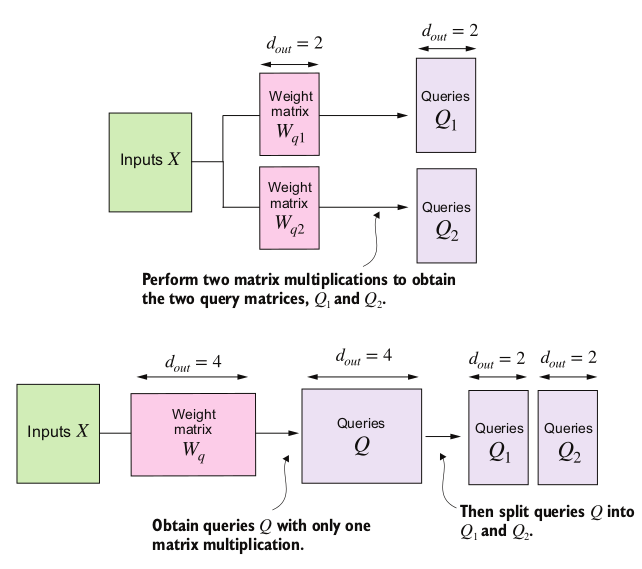

Idea is to optimize calculation, to limit number of matrix multiplications (in for loop). We could merge weight matrices, multiply wiht inputs and split afterwards.

In [92]:
class MultiHeadAttention(nn.Module):
    def __init__(self, input_emb_size, context_vect_size, max_context_length, dropout, num_heads=2, qkv_bias=False):
        super().__init__()

        assert (context_vect_size % num_heads == 0), "context_vect_size must be divisible by num heads"
        
        self.input_emb_size = input_emb_size
        self.context_vect_size = context_vect_size
        self.num_heads = num_heads
        self.context_vect_size_per_head = context_vect_size // num_heads

        #context_vect_size is bigger now; e.g. 4 instead of 2; all 'heads' in one matrix
        self.W_query= torch.nn.Linear(input_emb_size, context_vect_size, bias = qkv_bias) 
        self.W_key = torch.nn.Linear(input_emb_size, context_vect_size, bias = qkv_bias)
        self.W_value = torch.nn.Linear(input_emb_size, context_vect_size, bias = qkv_bias)

        self.out_proj = torch.nn.Linear(context_vect_size, context_vect_size) #Optional layer to learn dependencies between heads 
        
        self.dropout = nn.Dropout(dropout)
        self.causal_mask : torch.Tensor
        self.register_buffer(
            name="causal_mask",
            tensor=torch.triu(torch.ones(max_context_length, max_context_length, dtype=torch.bool), diagonal=1)
        )

    def forward(self, inputs):
        b, num_tokens, input_emb_size = inputs.shape
        keys = self.W_key(inputs)
        queries = self.W_query(inputs)
        values = self.W_value(inputs)
        
        # At this stage each of keys/queries/values stores the x values for each token (x = context_vect_size = num_heads * context_vect_size_per_head)
        #.view will split it in such way, that instead of 4 values (context_vect_size) we will have 2x2 matrix (num_heads x context_vect_size_per_head)
        # key/query/value of each token will have 2 sets of corresponding single context vectors of size context_vect_size_per_head; in basic case - 2 sets of 2 values for each token
        keys = keys.view(b, num_tokens, self.num_heads, self.context_vect_size_per_head)
        queries = queries.view(b, num_tokens, self.num_heads, self.context_vect_size_per_head)
        values = values.view(b, num_tokens, self.num_heads, self.context_vect_size_per_head)
        
        # Transpose (b, num_tokens, num_heads, context_vect_size_per_head) -> (b, num_heads, num_tokens, context_vect_size_per_head)
        # Result will be 2 sets (for each head) of 6x2 matrix (num_tokens x context_vect_size_per_head -> 2 values assigned to each token)
        # .transpose is swapping the dimensions with given indexes
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores: torch.Tensor = queries @ keys.transpose(2,3)
        attn_scores.masked_fill_(self.causal_mask[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        context_vecs = attn_weights @ values
        context_vecs = context_vecs.transpose(1,2)
        context_vecs = context_vecs.contiguous().view(b, num_tokens, self.context_vect_size)
        context_vecs = self.out_proj(context_vecs)
        
        return context_vecs


In [95]:
torch.manual_seed(123)
batch_size, max_context_length, input_emb_size = batch_inputs.shape
context_vect_size = 2
mha = MultiHeadAttention(input_emb_size, context_vect_size, max_context_length, 0.0, num_heads=2)
context_vecs = mha(batch_inputs)
print(context_vecs)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
